# Chapter 5 - Noise

Noise: colour, generation, autoregressive modelling, significance levels, and PSD estimators (Welch, Blackman-Tukey) - including a solar-wind turbulence application.

> The narrative chapter is in [`docs/chap5.md`](docs/chap5.md). This notebook reproduces every figure and table from that chapter, organised section-by-section so the code is easy to read alongside the prose.


## Setup

Common imports, plot styling and data paths used throughout this notebook.


In [1]:
import bottleneck as bn
import matplotlib
import matplotlib.dates as mdates
import matplotlib.patheffects as pe
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd
import scienceplots
import scipy
import scipy.signal
import scipy.special
import scipy.stats
import sklearn.decomposition
import astropy.io
import datetime
import astropy.time
import pandas as pd

from matplotlib.patches import Rectangle
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

plt.style.use(['science', 'nature', 'notebook', 'grid', 'high-vis'])

figsize_short = (8, 4)
figsize_normal = (8, 6)
figsize_tall = (8, 8)
plt.rcParams['figure.figsize'] = figsize_short
plt.rcParams['axes.labelpad'] = 6.0
plt.rcParams['legend.frameon'] = True
plt.rcParams['legend.framealpha'] = 0.8
plt.rcParams['legend.edgecolor'] = 'none'


title_font = {'fontsize': 16, 'weight': 'bold', 'style': 'italic'}
path_effect = [pe.withStroke(linewidth=2.0, foreground="k")]

read_path = 'docs/Data/'
save_path = 'docs/Figure/'

perula_df = pd.read_csv(read_path + 'matlab_perula.txt', header = None, sep = '\s+')
matlab_perula = matplotlib.colors.LinearSegmentedColormap.from_list('matlab_perula', np.array(perula_df))

jet_df = pd.read_csv(read_path + 'matlab_jet.txt', header = None, sep = '\s+')
matlab_jet = matplotlib.colors.LinearSegmentedColormap.from_list('matlab_jet', np.array(jet_df))

%matplotlib ipympl

<>:41: SyntaxWarning: invalid escape sequence '\s'
<>:44: SyntaxWarning: invalid escape sequence '\s'
<>:41: SyntaxWarning: invalid escape sequence '\s'
<>:44: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_1000/3118345031.py:41: SyntaxWarning: invalid escape sequence '\s'
  perula_df = pd.read_csv(read_path + 'matlab_perula.txt', header = None, sep = '\s+')
/tmp/ipykernel_1000/3118345031.py:44: SyntaxWarning: invalid escape sequence '\s'
  jet_df = pd.read_csv(read_path + 'matlab_jet.txt', header = None, sep = '\s+')


### `N = 2 ** 10`


/tmp/ipykernel_11326/3769427883.py:15: RuntimeWarning: divide by zero encountered in log10
  ax2.plot(freq, 10 * np.log10(psd), label='Power Spectral Density', color='C0')


0.9926862931925485
0.9543918843196101


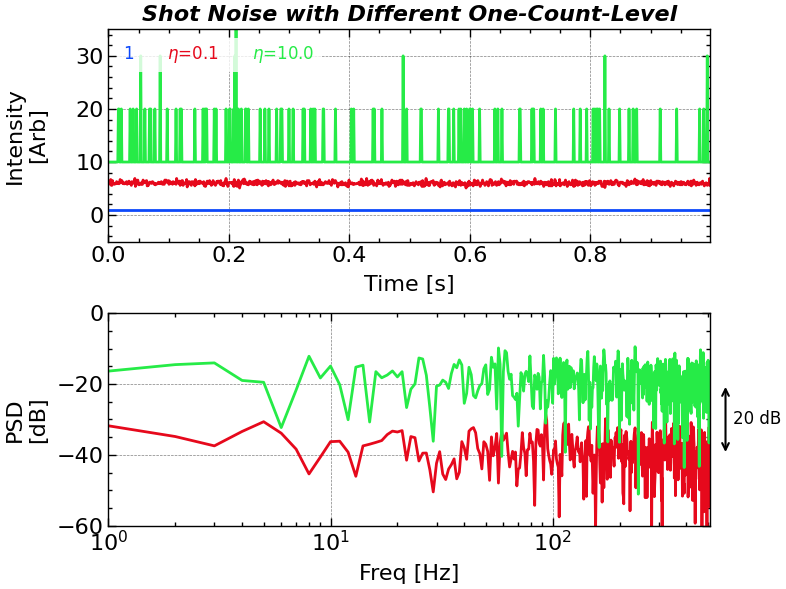

In [234]:
plt.close()
N = 2 ** 10

t = np.linspace(0, 1, N, endpoint=False)
dt = t[1] - t[0]
fs = 1 / dt
m = 0.3
sig = (1 + m * np.sin(20 * np.pi * t))
sig = 1 + 0 * t
plt.figure(figsize=figsize_normal)
ax1 = plt.subplot(2, 1, 1)
ax2 = plt.subplot(2, 1, 2)
ax1.plot(t, sig, label='1', color='C0')
freq, psd = scipy.signal.welch(sig, fs=fs, nperseg=N, window='hann')
ax2.plot(freq, 10 * np.log10(psd), label='Power Spectral Density', color='C0')

sig[sig < 0] = 0
for i, DETECTION_EFFICIENCY in enumerate([.1, 10.0, ][::-1]):
    sig_digitized = np.random.poisson(sig * DETECTION_EFFICIENCY) / DETECTION_EFFICIENCY
    ax1.plot(t, sig_digitized + (i + 1) * 5, linestyle = '-', label = r'$\eta$=' + f'{1/DETECTION_EFFICIENCY}')

    freq, psd = scipy.signal.welch(sig_digitized, fs=fs, nperseg=N, window='hann')
    ax2.plot(freq, 10 * np.log10(psd), linestyle = '-', label = f'{DETECTION_EFFICIENCY}')
    print(np.mean(psd) / (2 / DETECTION_EFFICIENCY / fs))
ax1.set_title('Shot Noise with Different One-Count-Level', **title_font)

# ax2.loglog()
ax2.set_xscale('log')
ax2.set_ylim(-60, 0)
ax1.set_ylim(-5, 35)
# ax2.set_ylim(1e-8, 1e-1)

ax1.legend(loc = 'upper left', ncol = 5, labelcolor="linecolor", handlelength = 0, handletextpad = 0, prop = {'weight': 'normal', 'size' : 12})
ax1.set_xlabel('Time [s]')
ax1.set_ylabel('Intensity\n[Arb]')
ax2.set_xlabel('Freq [Hz]')
# ax2.set_ylabel('PSD\n[Arb$^2$/Hz]')
ax2.set_ylabel('PSD\n[dB]')
# ax2.yaxis.set_minor_locator(ticker.LogLocator(base=10.0, numticks=50))
# ax2.yaxis.set_minor_formatter(ticker.NullFormatter())
ax1.autoscale(enable=True, axis='x', tight=True)
ax2.autoscale(enable=True, axis='x', tight=True)

ax1.yaxis.set_label_coords(-0.1, 0.5)
ax2.yaxis.set_label_coords(-0.1, 0.5)

ax2.text(650, -30, '20 dB', fontsize=12, color='k', va = 'center')
ax2.annotate('', (600, -40), (600, -20), arrowprops=dict(arrowstyle='<->', lw=1.5), fontsize=12, color='k', ha='center', annotation_clip=False)

plt.tight_layout()

plt.savefig(save_path + 'figure_shot_noise' + '.png', bbox_inches='tight', dpi=300)

plt.show()

### `N = 2 ** 10`


<>:13: SyntaxWarning: invalid escape sequence '\p'
<>:13: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_923/2358005247.py:13: SyntaxWarning: invalid escape sequence '\p'
  ax1.plot(t, sig, label='sin(20$\pi$t) + 3t', color='C0')


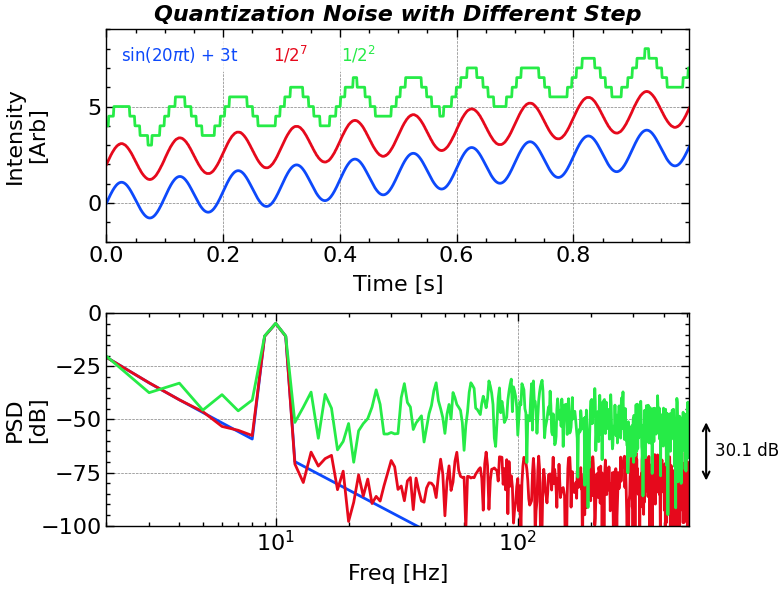

In [5]:
plt.close()
N = 2 ** 10

t = np.linspace(0, 1, N, endpoint=False)
dt = t[1] - t[0]
fs = 1 / dt
sig = np.sin(2 * np.pi * 10 * t) + 3 * t
# sig = t

plt.figure(figsize=figsize_normal)
ax1 = plt.subplot(2, 1, 1)
ax2 = plt.subplot(2, 1, 2)
ax1.plot(t, sig, label='sin(20$\pi$t) + 3t', color='C0')
freq, psd = scipy.signal.welch(sig, fs=fs, nperseg=N, window='hann')
ax2.plot(freq, 10 * np.log10(psd), label='Power Spectral Density', color='C0')

for i, N_BIT in enumerate([2, 7][::-1]):
    DELTA = 2 / (2 ** N_BIT)
    # sig_digitized = RANGE[np.digitize(sig - AMPLITUDE / 2 / N_DIGITS, RANGE)]
    sig_digitized = DELTA * np.round(sig / DELTA)
    ax1.plot(t, sig_digitized + (i + 1) * 2, linestyle = '-', label = f'1/2$^{N_BIT:d}$')

    freq, psd = scipy.signal.welch(sig_digitized, fs=fs, nperseg= N, window='hann')
    ax2.plot(freq, 10 * np.log10(psd), linestyle = '-')


ax1.set_title('Quantization Noise with Different Step', **title_font)

# ax2.loglog()
ax2.set_xscale('log')

ax1.set_ylim(-2, 9)
# ax2.set_ylim(1e-10, 1e0)
ax2.set_ylim(-100, 0)
ax2.set_xlim(2, 512)
ax1.legend(loc = 'upper left', ncol = 5, labelcolor="linecolor", handlelength = 0, handletextpad = 0, prop = {'weight': 'normal', 'size' : 12})
ax1.set_xlabel('Time [s]')
ax1.set_ylabel('Intensity\n[Arb]')
ax2.set_xlabel('Freq [Hz]')
ax2.set_ylabel('PSD\n[dB]')
# ax2.yaxis.set_minor_locator(ticker.LogLocator(base=10.0, numticks=50))
# ax2.yaxis.set_minor_formatter(ticker.NullFormatter())
ax1.autoscale(enable=True, axis='x', tight=True)
# ax2.autoscale(enable=True, axis='x', tight=True)

ax1.yaxis.set_label_coords(-0.1, 0.5)
ax2.yaxis.set_label_coords(-0.1, 0.5)
ax2.text(650, -65.05, '30.1 dB', fontsize=12, color='k', va = 'center')
ax2.annotate('', (600, -80.1), (600, -50), arrowprops=dict(arrowstyle='<->', lw=1.5), fontsize=12, color='k', ha='center', annotation_clip=False)
plt.tight_layout()

plt.savefig(save_path + 'figure_quantization_noise' + '.png', bbox_inches='tight', dpi=300)

plt.show()

### `plt.cla()`


<>:69: SyntaxWarning: invalid escape sequence '\m'
<>:69: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_1000/1256939088.py:69: SyntaxWarning: invalid escape sequence '\m'
  ax1.set_ylabel('PSD [$\mathrm{Arb^2/Hz}$]')


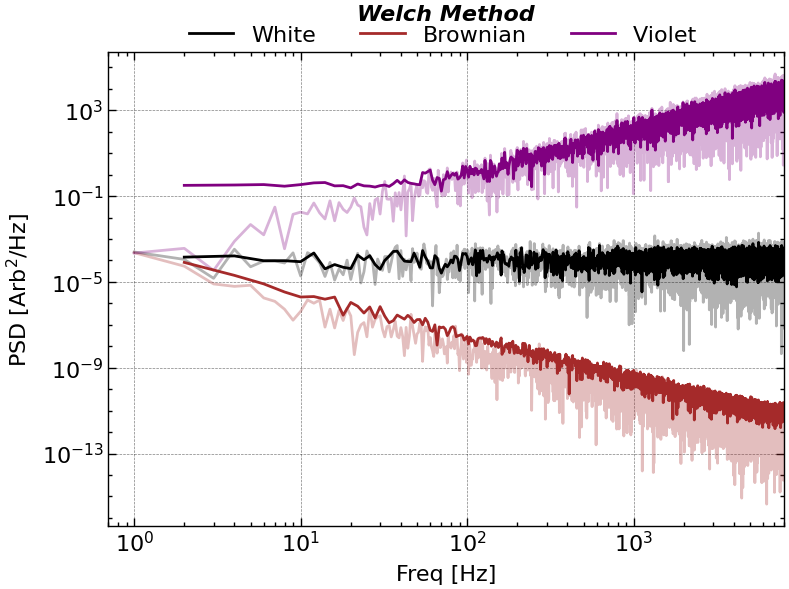

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import scienceplots
plt.style.use(['science', 'nature', 'notebook', 'grid', 'high-vis'])

%matplotlib ipympl
plt.close()
plt.cla()
plt.clf()
# plt.figure(figsize=figsize_short)
ax1 = plt.subplot(1, 1, 1)

N = 2 ** 14
t = np.linspace(0, 1, N, endpoint=False)
fs = 1 / (t[1] - t[0])
freq = np.fft.rfftfreq(len(t), t[1] - t[0])

N_PER_SEG = 2 ** 13
window = 'boxcar'
noise_white = np.random.randn(t.size)

coef_white = np.fft.rfft(noise_white, axis=-1).T
psd_white = (np.abs(coef_white) ** 2) / fs / t.size
psd_white[1:] *= 2  # Adjust for one-sided spectrum

freq_welch, psd_white_welch = scipy.signal.welch(noise_white, fs, window = window, nperseg=N_PER_SEG)

noise_brownian_fft = np.fft.rfft(np.random.randn(t.size))
noise_brownian_fft[1:] /= freq[1:] ** 1
noise_brownian_fft[0] = 0
noise_brownian = np.fft.irfft(noise_brownian_fft)

coef_brownian = np.fft.rfft(noise_brownian, axis=-1).T
psd_brownian = (np.abs(coef_brownian) ** 2) / fs / t.size
psd_brownian[1:] *= 2  # Adjust for one-sided spectrum

freq_welch, psd_brownian_welch = scipy.signal.welch(noise_brownian, fs, window = window, nperseg=N_PER_SEG)

noise_violet_fft = np.fft.rfft(np.random.randn(t.size))
noise_violet_fft[1:] /= freq[1:] ** -1
noise_violet_fft[0] = 0
noise_violet = np.fft.irfft(noise_violet_fft)

coef_violet = np.fft.rfft(noise_violet, axis=-1).T
psd_violet = (np.abs(coef_violet) ** 2) / fs / t.size
psd_violet[1:] *= 2  # Adjust for one-sided spectrum

# freq, psd_violet = scipy.signal.welch(noise_violet, fs, window = window, nperseg=N)

freq_welch, psd_violet_welch = scipy.signal.welch(noise_violet, fs, window = window, nperseg=N_PER_SEG)

ax1.plot(freq[1:], psd_white[1:], 'k-', alpha = 0.3)
ax1.plot(freq[1:], psd_brownian[1:], color = 'brown', linestyle = '-', alpha = 0.3)
ax1.plot(freq[1:], psd_violet[1:], color = 'purple', linestyle = '-', alpha = 0.3)

ax1.plot(freq_welch[1:], psd_white_welch[1:], 'k-', label = 'White')
ax1.plot(freq_welch[1:], psd_brownian_welch[1:], color = 'brown', linestyle = '-', label = 'Brownian')
ax1.plot(freq_welch[1:], psd_violet_welch[1:], color = 'purple', linestyle = '-', label = 'Violet ')

ax1.set_yscale('log')
ax1.set_xscale('log')

ax1.yaxis.set_major_locator(ticker.LogLocator(base=10.0, subs='all', numticks=6))
ax1.yaxis.set_minor_locator(ticker.LogLocator(base=10.0, subs='all', numticks=100))
ax1.yaxis.set_minor_formatter(ticker.NullFormatter())
ax1.legend(frameon = False, bbox_to_anchor = (0.5, 1.10), loc = 'upper center', ncol = 5)

ax1.set_xlabel('Freq [Hz]')
ax1.set_ylabel('PSD [$\mathrm{Arb^2/Hz}$]')


ax1.set_xlim(0.7, 8e3)

ax1.set_title('Welch Method', y = 1.05, **title_font)
plt.tight_layout()

plt.savefig(save_path + 'figure_noise_welch' + '.png',bbox_inches='tight',dpi=300)

plt.show()

### `plt.cla()`


1727078.122627045


<>:60: SyntaxWarning: invalid escape sequence '\m'
<>:60: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_1000/1306604236.py:60: SyntaxWarning: invalid escape sequence '\m'
  ax1.set_ylabel('PSD [$\mathrm{Arb^2/Hz}$]')
/tmp/ipykernel_1000/1306604236.py:46: RuntimeWarning: divide by zero encountered in divide
  psd_ideal = 2 / freq / freq / N


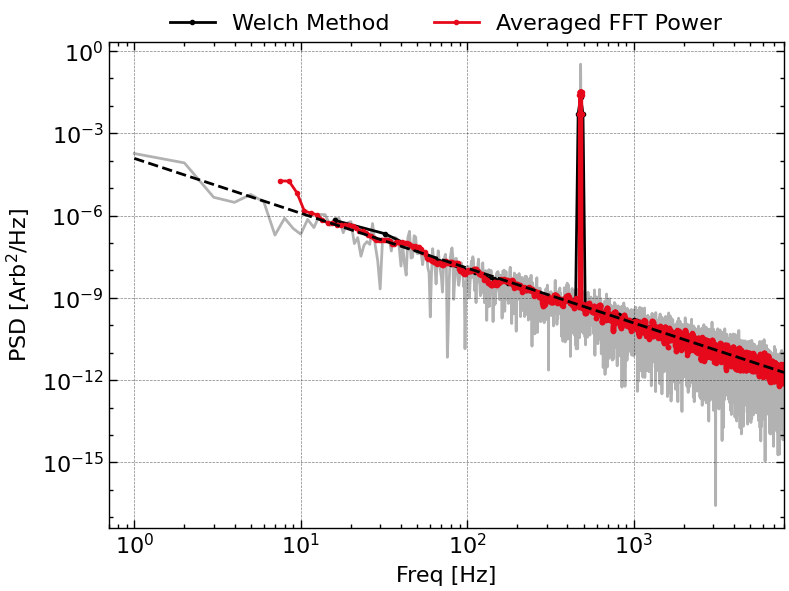

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scienceplots
plt.style.use(['science', 'nature', 'notebook', 'grid', 'high-vis'])

%matplotlib ipympl
plt.close()
plt.cla()
plt.clf()
# plt.figure(figsize=figsize_short)
ax1 = plt.subplot(1, 1, 1)

N = 2 ** 14
t = np.linspace(0, 1, N, endpoint=False)
fs = 1 / (t[1] - t[0])
freq = np.fft.rfftfreq(len(t), t[1] - t[0])

N_SEG = 16
N_PER_SEG = int(N / N_SEG)
window = 'hann'

noise_brownian_fft = np.fft.rfft(np.random.randn(t.size))
noise_brownian_fft[1:] /= freq[1:] ** 1
noise_brownian_fft[0] = 0
sig = np.fft.irfft(noise_brownian_fft)

# sig = np.random.randn(t.size)

sig += np.cos(2 * np.pi * 480 * t)

coef_white = np.fft.rfft(sig * np.hanning(sig.size), axis=-1).T
psd_white = (np.abs(coef_white) ** 2) / fs / t.size
psd_white[1:] *= 2  # Adjust for one-sided spectrum
psd_white[1:] *= 8 / 3  # Adjust for one-sided spectrum

freq_welch, psd_white_welch = scipy.signal.welch(sig, fs, window = window, nperseg=N_PER_SEG)

ax1.plot(freq[1:], psd_white[1:], 'k-', alpha = 0.3)

ax1.plot(freq_welch[1:], psd_white_welch[1:], 'ko-', label = 'Welch Method')

freq_downsampled = bn.move_mean(freq, N_SEG)[int(N_SEG / 2)::N_SEG]
psd_downsampled = bn.move_mean(psd_white, N_SEG)[int(N_SEG / 2)::N_SEG]
# ax1.plot(freq[::N_SEG], np.roll(bn.move_mean(psd_white, N_SEG), -int(N_SEG / 2))[::N_SEG], 'C1o-', label = 'Averaged FFT')
ax1.plot(bn.move_mean(freq, N_SEG)[int(N_SEG / 2)::1], bn.move_mean(psd_white, N_SEG)[int(N_SEG / 2)::1], 'C1o-', label = 'Averaged FFT Power')
# ax1.plot(bn.move_mean(freq, N_SEG)[::N_SEG], np.abs(bn.move_mean(coef_white, N_SEG)[::N_SEG]) ** 2 / fs / t.size, 'C0o-', label = 'Averaged FFT Coef')

psd_ideal = 2 / freq / freq / N
ax1.plot(freq, psd_ideal, 'k--')

print(np.std(psd_white_welch[1:] / psd_ideal[1::N_SEG]))

ax1.set_yscale('log')
ax1.set_xscale('log')

ax1.yaxis.set_major_locator(ticker.LogLocator(base=10.0, subs='all', numticks=6))
ax1.yaxis.set_minor_locator(ticker.LogLocator(base=10.0, subs='all', numticks=100))
ax1.yaxis.set_minor_formatter(ticker.NullFormatter())
ax1.legend(frameon = False, bbox_to_anchor = (0.5, 1.10), loc = 'upper center', ncol = 5)

ax1.set_xlabel('Freq [Hz]')
ax1.set_ylabel('PSD [$\mathrm{Arb^2/Hz}$]')


ax1.set_xlim(0.7, 8e3)

# ax1.set_title('Welch Method', y = 1.05, **title_font)
plt.tight_layout()

# plt.savefig(save_path + 'figure_noise_welch' + '.png',bbox_inches='tight',dpi=300)

plt.show()

### `def get_ar2_coefficients(omega, r):`


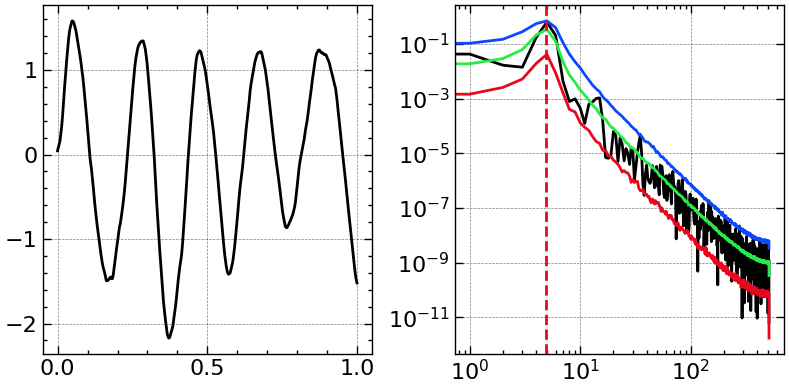

In [ ]:
from scipy.signal import lfilter, welch

def get_ar2_coefficients(omega, r):
    return 2 * r * np.cos(omega), -r**2

def generate_ar2(phi1, phi2, N):
    noise = np.random.normal(0, np.sqrt(1), 2 * N)
    a = [1, -phi1, -phi2]  # 分母系数 (AR部分)
    b = [1]                # 分子系数 (MA部分，此处仅为白噪声)
    x = lfilter(b, a, noise)[N:]
    return x

N = 2 ** 10
t = np.linspace(0, 1, N, endpoint=False)
dt = t[1] - t[0]
# 2. 生成高斯白噪声
noise = np.random.normal(0, np.sqrt(1), 2 * N)

# 3. 构建滤波器系数
# 差分方程: X_t - phi1*X_{t-1} - phi2*X_{t-2} = epsilon_t
omega = 0.03
r = 1 - 3e-3
phi1, phi2 = get_ar2_coefficients(omega, r)
a = [1, -phi1, -phi2]  # 分母系数 (AR部分)
b = [1]                # 分子系数 (MA部分，此处仅为白噪声)

# 4. 滤波生成信号
x = lfilter(b, a, noise)[N:]

plt.close()
ax1 = plt.subplot(1, 2, 1)
ax2 = plt.subplot(1, 2, 2)

N_REPEAT = 1000
psds = np.zeros((N_REPEAT, len(x) // 2 + 1))

for i in range(N_REPEAT):
    x = generate_ar2(phi1, phi2, N)
    x -= np.mean(x)
    x /= np.std(x)
    freq, psds[i] = welch(x, fs=1/dt, nperseg=N, window='hann')

ax1.plot(t, x, 'k-')

# ax2.plot(freq, np.median(np.percentile(psds, [25, 50, 75], axis=0), axis = 0), 'C0-')
# ax2.plot(freq, np.std(psds, axis = 0) / np.mean(psds, axis = 0), 'C0-')
# ax2.set_ylim(0, 1.5)

ax2.plot(freq, psds[-1], 'k-')

ax2.plot(freq, np.percentile(psds, [5], axis=0)[0], 'C1-')
ax2.plot(freq, np.percentile(psds, [50], axis=0)[0], 'C2-')
ax2.plot(freq, np.percentile(psds, [95], axis=0)[0], 'C0-')

# ax2.plot(freq, np.mean(psds, axis = 0), 'C0-')
ax2.axvline(omega / (2 * np.pi) / dt, color='C1', linestyle='--', label=r'$\omega/2\pi$')
ax2.loglog()
# ax2.set_yscale('log')
plt.tight_layout()
plt.show()

### `jax.numpy.linalg.svd(a, full_matrices=False)`


In [16]:
%%timeit -r 10 -t 10
jax.numpy.linalg.svd(a, full_matrices=False)

163 ms ± 9.12 ms per loop (mean ± std. dev. of 10 runs, 100 loops each)


### AR(1) noise: effect of autocorrelation parameter

AR(1) realisations with different lag-1 autocorrelation coefficients α show how memory shapes the time series.

In [ ]:
def ar1(alpha, N):
    sig = np.zeros(N)
    for i in range(1, N):
        sig[i] = sig[i - 1] * alpha + np.random.randn()
    return sig

plt.close()
ax1 = plt.subplot()
N = 2 ** 10

for i, alpha in enumerate([0.10, 0.90, 0.99]):
    sig = ar1(alpha, N)
    cov0 = (sig * sig).mean()
    cov1 = (sig[:-1] * sig[1:]).mean()
    gamma = cov1 / cov0
    _alpha = np.sqrt((1 - gamma ** 2) * cov0)
    print(alpha, gamma)
    ax1.plot(sig + i * 25, linestyle = '-', label = r'$\alpha=$' + f"{alpha:.2f}")

ax1.legend(ncol = 3)
ax1.set_ylim(-9, 85)
ax1.autoscale(axis = 'x', tight = True)
ax1.set_xlabel('Time [$\mathrm{\delta t}$]')
ax1.set_ylabel('Intensity [Arb]')
plt.tight_layout()
plt.show()

### Colored noise: white, Brownian, and violet

Generating white, Brownian (red), and violet noise by integrating or differentiating white noise, then comparing their PSDs.

In [ ]:
plt.close()
ax1 = plt.subplot(1, 1, 1)

N = 2 ** 13
t = np.linspace(0, 1, N, endpoint=False)
dt = t[1] - t[0]
fs = 1 / dt
freq = np.fft.rfftfreq(len(t), t[1] - t[0])

noise_white = np.random.randn(t.size)
coef_white = np.fft.rfft(noise_white, axis=-1).T
psd_white = (np.abs(coef_white) ** 2) / fs / t.size

noise_brownian = np.cumsum(np.random.randn(t.size)) * dt
coef_brownian = np.fft.rfft(noise_brownian, axis=-1).T
psd_brownian = (np.abs(coef_brownian) ** 2) / fs / t.size

noise_violet = np.diff(np.random.randn(t.size + 1)) / dt
coef_violet = np.fft.rfft(noise_violet, axis=-1).T
psd_violet = (np.abs(coef_violet) ** 2) / fs / t.size

ax1.plot(freq[1:], psd_white[1:], 'k-', label = 'White')
ax1.plot(freq[1:], psd_brownian[1:], color = 'brown', linestyle = '-', label = 'Brownian')
ax1.plot(freq[1:], psd_violet[1:], color = 'purple', linestyle = '-', label = 'Violet')

# ax1.plot(freq[1:], np.ones_like(freq[1:]) / fs, 'k--', alpha = 0.5, zorder = 1)

ax1.set_yscale('log')
ax1.set_xscale('log')

ax1.grid('on', linestyle = '--', alpha = 0.5)

ax1.legend(frameon = False, bbox_to_anchor = (0.5, 1.10), loc = 'upper center', ncol = 5)

ax1.set_xlabel('Freq [Hz]')
ax1.set_ylabel('PSD [$\mathrm{Arb^2/Hz}$]')

ax1.yaxis.set_major_locator(ticker.LogLocator(base=10.0, subs='all', numticks=6))
ax1.yaxis.set_minor_locator(ticker.LogLocator(base=10.0, subs='all', numticks=100))
ax1.yaxis.set_minor_formatter(ticker.NullFormatter())

ax1.set_title('Power Spectral Density of Noise Types', y = 1.05, **title_font)

ax1.text(50, 1e3, '${\propto f^2}$', fontsize=20, rotation = 20, ha='center', va='center', color='purple', alpha=1.0)
ax1.text(50, 2e-13, '${\propto 1/f^{2}}$', fontsize=20, rotation = -20, ha='center', va='center', color='brown', alpha=1.0)

plt.tight_layout()

plt.savefig(save_path + 'figure_noise' + '.png',bbox_inches='tight',dpi=300)

plt.show()

### Chi-squared distribution of PSD coefficients

The PSD of white noise at each frequency bin follows an exponential (chi-squared with 2 DOF) distribution.

In [ ]:
plt.close()
plt.figure(figsize=figsize_short)

ax1 = plt.subplot(1, 1, 1)

N = 2 ** 13
t = np.linspace(0, 1, N, endpoint=False)
fs = 1 / (t[1] - t[0])
freq = np.fft.rfftfreq(len(t), t[1] - t[0])

noise_white = np.random.randn(t.size)

coef_white = np.fft.rfft(noise_white, axis=-1).T
psd_white = (np.abs(coef_white) ** 2) / fs / t.size

bins = np.linspace(0, 10, 50)

ax1.hist(psd_white[1:] * fs , bins=bins, color='C0', alpha=0.75, density = True, label = f'Frequency-wise')

N_SAMPLE = int(t.size / 2)
psd_white_at_100_Hz = np.zeros(N_SAMPLE)
for i in range(N_SAMPLE):
    noise_white = np.random.randn(t.size)

    coef_white = np.fft.rfft(noise_white, axis=-1).T
    psd_white = (np.abs(coef_white) ** 2) / fs / t.size
    psd_white_at_100_Hz[i] = psd_white[100 + 1]

ax1.hist(-psd_white_at_100_Hz * fs, bins=-bins[::-1], color='C1', alpha=0.75, density = True, label = 'Realization-wise')

ax1.plot(bins, 1 * np.exp(-bins), 'k--', alpha = 0.5, zorder = 1, label = 'PSD/$f_s \sim \chi_2^2$')
ax1.plot(-bins, 1 * np.exp(-bins), 'k--', alpha = 0.5, zorder = 1)


for ax in [ax1]:

    ax.legend(frameon = False, loc = 'upper left', ncol = 2)

    ax.set_xlabel('PSD/$f_s$ [$\mathrm{V^2/Hz^2}$]')
    ax.set_ylabel('#')

ax1.set_ylim(0, 1.2)
ax1.set_title('Histogram of Power Spectral Density\nfor White Noise', **title_font)
plt.tight_layout()

plt.savefig(save_path + 'figure_noise_hist' + '.png',bbox_inches='tight',dpi=300)

plt.show()

### Non-central chi-squared: signal embedded in noise

When a sinusoid is buried in white noise, the PSD at the signal frequency follows a non-central chi-squared distribution; this forms the basis of significance testing.

In [ ]:
plt.close()
ax1 = plt.subplot(1, 1, 1)

N = 10000

t = np.linspace(0, 1, N, endpoint=False)
fs = 1 / (t[1] - t[0])

omega = 2 * np.pi * 100
freq = np.fft.rfftfreq(len(t), t[1] - t[0])
freq_idx = np.where(freq == omega / (2 * np.pi))[0][0]

bins = np.linspace(0, 400.0, 200, endpoint=False)
bin_width = bins[1] - bins[0]
fined_bins = np.linspace(0, 400, 20000)[1:]


N_SAMPLE = 10000
psd_at_wave_frequency = np.zeros(N_SAMPLE)
amp_signal = [0.00, 0.07, 0.10]
amp_noise = [1.00, 1.00, 1.00]

for i in range(3):
    for j in range(N_SAMPLE):
        sig = amp_signal[i] * np.sin(omega * t) + amp_noise[i] * np.random.randn(t.size)
        _, psd = scipy.signal.welch(sig, fs, window='boxcar', nperseg=N)
        psd_at_wave_frequency[j] = psd[freq_idx]
    ax1.hist(psd_at_wave_frequency * fs, bins = bins, alpha=0.75, label = "$\mathit{SNR}$:" + f"{(amp_signal[i] / amp_noise[i]) ** 2 / 2:.4f}")
    # ax1.hist(psd_at_wave_frequency * fs, bins = bins, alpha=0.75)

    # fit_result = scipy.stats.ncx2.fit(psd_at_wave_frequency * fs, method = 'MLE', fdf = 2, floc = 0)
    # print(fit_result)
    # ax1.plot(fined_bins, N_SAMPLE * bin_width * scipy.stats.ncx2.pdf(fined_bins, *fit_result), 'k--', alpha = 0.75, zorder = 1)
    # (x, df, nc, loc, scale)
    nc = (amp_signal[i] ** 2 / 2) * N
    scale = amp_noise[i] ** 2
    # print(nc, scale)
    ax1.plot(fined_bins, N_SAMPLE * bin_width * scipy.stats.ncx2.pdf(fined_bins, df = 2, nc = nc, loc = 0, scale = scale), 'k--', alpha = 0.75, zorder = 1)
    
ax1.legend(frameon = False, loc = 'upper right', ncol = 1)

ax1.set_xlabel('PSD/$f_s$ [$\mathrm{Arb^2/Hz^2}$]')
ax1.set_ylabel('#')

# ax1.set_xlim(0, 68)
# ax1.set_yscale('symlog', linthresh = 1e1)
# ax1.set_ylim(1e0, 1e4)

ax1.set_ylim(0, 1210)
ax1.set_xlim(0, 99)

# ax1.set_title('Signal Over Noise PSD', **title_font)
ax1.set_title('Histogram of Power Spectral Density\nfor Signal + White Noise', **title_font)

plt.tight_layout()
plt.savefig(save_path + 'figure_signal_over_noise_hist' + '.png',bbox_inches='tight',dpi=300)

plt.show()

### Gamma distribution

The Gamma distribution is the generalized form of the chi-squared and exponential distributions used in PSD significance testing.

In [ ]:
plt.close()

plt.figure(figsize=figsize_short)
ax1 = plt.subplot(1, 1, 1)
sig = np.linspace(0, 20, 100000, endpoint=False)

parameters = [(1.0, 2.0), (2.0, 2.0), (5.0, 1.0), (9.0, 0.5), (7.5, 1.0), (0.5, 1.0)]
colors = ['r', 'orange', 'yellow', 'lime', 'k', 'blue', 'm']

for i in np.arange(len(parameters)):
    alpha = parameters[i][0]
    theta = parameters[i][1]
    color = colors[i]
    pdf = scipy.stats.gamma.pdf(sig, alpha, 0, theta)
    pdf[pdf == 0] = np.nan
    # ax1.plot(x, pdf, color = color, linestyle = '-', label = r"$\alpha$ = %.2f, $\lambda$ = %.2f" % (alpha, 1 / theta))
    ax1.plot(sig, pdf, color = f"C{i}", label = r"$\alpha$ = %.2f, $\lambda$ = %.2f" % (alpha, 1 / theta))

ax1.legend(frameon = False, loc = 'upper right')

ax1.set_ylim(0, 0.5)
ax1.set_xlim(0, 20)

ax1.set_xlabel('$x$')
ax1.set_ylabel(r'PDF(${x}$)')

ax1.set_title(r'Gamma Distribution $\Gamma(\alpha,\lambda)$')

plt.tight_layout()

plt.savefig(save_path + 'figure_gamma_distribution' + '.png',bbox_inches='tight',dpi=300)

plt.show()

## Application: solar-wind turbulence spectrum

Synthesise a magnetic-field signal with a Kolmogorov $f^{-5/3}$ inertial range and a steeper kinetic range past the ion-scale break, then recover the spectral indices with Welch's method.

In [ ]:
import numpy as np, scipy.signal
import matplotlib.pyplot as plt
import scienceplots, matplotlib.ticker as ticker
plt.style.use(['science', 'nature', 'notebook', 'grid', 'high-vis'])

rng = np.random.default_rng(20240630)

# ---- sampling: search-coil + fluxgate cadence over ~9 h ----
fs = 256.0                     # Hz  -> Nyquist 128 Hz (reaches electron scales)
N  = 2 ** 23                   # ~8.39e6 samples -> ~9.1 h (reaches f ~ 3e-5 Hz)
t  = np.arange(N) / fs
freq = np.fft.rfftfreq(N, 1 / fs)

# ---- target trace power spectrum: four ranges, two breaks ----
# slopes after Verscharen, Klein & Maruca (2019), Living Rev. Sol. Phys. 16:5
f1  = 1e-3        # injection -> inertial   (correlation scale)
f_i = 0.3         # ion-scale break
f_e = 40.0        # electron-scale break
a_inj, a_in, a_kin, a_el = 1.0, 5 / 3, 2.8, 4.0

def target_psd(f):
    f_ = f.copy(); f_[0] = f_[1]
    P = f_ ** (-a_inj)                                              # 1/f injection
    A = 1.0
    C1 = A * f1 ** (-a_inj + a_in)
    m = f_ >= f1;  P[m] = C1 * f_[m] ** (-a_in)                     # -5/3 inertial
    C2 = C1 * f_i ** (-a_in + a_kin)
    m = f_ >= f_i; P[m] = C2 * f_[m] ** (-a_kin)                    # -2.8 ion kinetic
    C3 = C2 * f_e ** (-a_kin + a_el)
    m = f_ >= f_e; P[m] = C3 * f_[m] ** (-a_el)                     # -4 electron range
    P[0] = 0.0
    return P

Ptar = target_psd(freq)

def synth(P):
    g = (rng.standard_normal(len(P)) + 1j * rng.standard_normal(len(P))) / np.sqrt(2)
    spec = g * np.sqrt(P); spec[0] = 0.0
    return np.fft.irfft(spec, n=N)

b = np.stack([synth(Ptar) for _ in range(3)], axis=0)
b *= 5.0 / b.std(axis=1, keepdims=True)            # ~5 nT fluctuation level
b += np.array([4.0, -2.0, 1.0])[:, None]           # arbitrary mean field
bx, by, bz = b

# ---- Welch trace PSD ----
nperseg = 2 ** 20              # lowest resolved f ~ 2.4e-4 Hz (shows the 1/f range)
fw, Px = scipy.signal.welch(bx, fs, window='hann', nperseg=nperseg)
_,  Py = scipy.signal.welch(by, fs, window='hann', nperseg=nperseg)
_,  Pz = scipy.signal.welch(bz, fs, window='hann', nperseg=nperseg)
Ptr = Px + Py + Pz

def slope(fa, fb_):
    m = (fw >= fa) & (fw <= fb_)
    s, c = np.polyfit(np.log10(fw[m]), np.log10(Ptr[m]), 1)
    return s, c
s_in,  c_in  = slope(3e-3, 0.1)
s_kin, c_kin = slope(0.6, 10.0)
s_el,  c_el  = slope(50.0, 110.0)

# ---- figure ----
plt.close()
plt.figure(figsize=(8.8, 3.9))
ax1 = plt.subplot(1, 2, 1)
ax2 = plt.subplot(1, 2, 2)

w = (t >= 5000) & (t < 5000 + 1800)
ax1.plot(t[w] - 5000, bx[w], lw=0.5, color='#0d49fb', label='$B_x$')
ax1.plot(t[w] - 5000, by[w], lw=0.5, color='#e6091c', label='$B_y$')
ax1.plot(t[w] - 5000, bz[w], lw=0.5, color='#222222', label='$B_z$')
ax1.set_xlabel('Time [s]'); ax1.set_ylabel('B [nT]'); ax1.set_xlim(0, 1800)
ax1.legend(frameon=False, ncol=1, loc='upper right',
           labelcolor=['#0d49fb', '#e6091c', '#222222'], handlelength=1.1, fontsize=9)
ax1.set_title('Turbulent field (30 min)', pad=8, **title_font)

def logbin(f, P, n=80):
    e = np.logspace(np.log10(f[1]), np.log10(f[-1]), n + 1)
    idx = np.digitize(f, e)
    fc = np.array([f[idx == k].mean() for k in range(1, n + 1)])
    Pc = np.array([P[idx == k].mean() for k in range(1, n + 1)])
    ok = np.isfinite(fc) & np.isfinite(Pc)
    return fc[ok], Pc[ok]

ax2.loglog(fw[1:], Ptr[1:], color='#cccccc', lw=0.5, alpha=0.7, zorder=1)
fb_, Pb_ = logbin(fw[1:], Ptr[1:])
ax2.loglog(fb_, Pb_, color='#0d49fb', lw=1.5, ls='-', zorder=3, label='trace PSD (Welch)')

# fit guides for the two headline ranges (legend)
ff = np.logspace(np.log10(2e-3), np.log10(0.18), 50)
ax2.loglog(ff, 10 ** c_in * ff ** s_in, '--', color='#e6091c', lw=1.3, zorder=4,
           label=r'$f^{-5/3}$  Kolmogorov')
fk = np.logspace(np.log10(0.5), np.log10(20), 50)
ax2.loglog(fk, 10 ** c_kin * fk ** s_kin, '--', color='#222222', lw=1.3, zorder=4,
           label=fr'$f^{{{s_kin:.1f}}}$  ion kinetic')

ax2.set_xlim(1.5e-4, 1.6e2)
ymin, ymax = ax2.get_ylim()

# break markers (dotted verticals) with labels along the top
for fb0, lbl in [(f_i, 'ion break'), (f_e, 'electron break')]:
    ax2.axvline(fb0, color='#888888', ls=':', lw=0.9, zorder=2)
    ax2.text(fb0 * 0.82, ymax * 0.4, lbl, fontsize=7.5, color='#555555',
             rotation=90, va='top', ha='center')

# on-curve labels for the secondary ranges
ax2.text(2.4e-4, ymax * 0.35, r'$f^{-1}$', fontsize=9, color='#555555')
ax2.text(78, 10 ** c_el * 78 ** s_el * 5.0, r'$f^{-4}$', fontsize=9, color='#555555', ha='center')

ax2.set_xlabel('Frequency [Hz]'); ax2.set_ylabel(r'Trace PSD [$\mathrm{nT^2/Hz}$]')
ax2.legend(frameon=False, loc='lower left', fontsize=7.5)
ax2.set_title('Solar-wind turbulence spectrum', **title_font)

plt.tight_layout()
plt.savefig(save_path + 'figure_solar_wind_turbulence' + '.png', bbox_inches='tight', dpi=300)
plt.show()

## Further reading

The narrative chapter, complete with derivations and references, is in [`docs/chap5.md`](docs/chap5.md). For the full table of contents see [`docs/_sidebar.md`](docs/_sidebar.md).
